# **Week 2. Supervised Learning**

2주차 과제는 지도학습의 회귀, 분류 모델을 학습-평가하는 과정을 간소하게 재현한 코드입니다.

1. 적힌 코드를 따라가며, 배운 내용과 어떻게 연관되는지 등을 생각하거나 찾아본 후, 주석으로 달아주시면 좋을 것 같습니다.
2. 더불어 생각해볼 만한 질문들을 중간에 달아두었으니, 이에 대한 고민과 답변을 작성해주시면 됩니다.

# **1. 회귀 - with diabetes dataset**

In [1]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 그래프에 한글이 깨지지 않도록 폰트 설정 (폰트 파일 경로로 직접 등록해서 이름 인식 실패를 방지)
malgun_path = r"C:\Windows\Fonts\malgun.ttf"
fm.fontManager.addfont(malgun_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=malgun_path).get_name()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 기호가 깨지는 것 방지

## 1. 데이터 로드 및 탐색

In [2]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

In [3]:
# 데이터 크기와 피처(특성) 정보 출력
print(f"Dataset Shape: {X.shape}")  # ( , )
print(f"Feature Names: {diabetes.feature_names}")
print(f"Target (y) Sample: {y[:5]}")  # 타겟 값 일부 확인

Dataset Shape: (442, 10)
Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target (y) Sample: [151.  75. 141. 206. 135.]


In [4]:
# 데이터프레임으로 변환하여 탐색
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


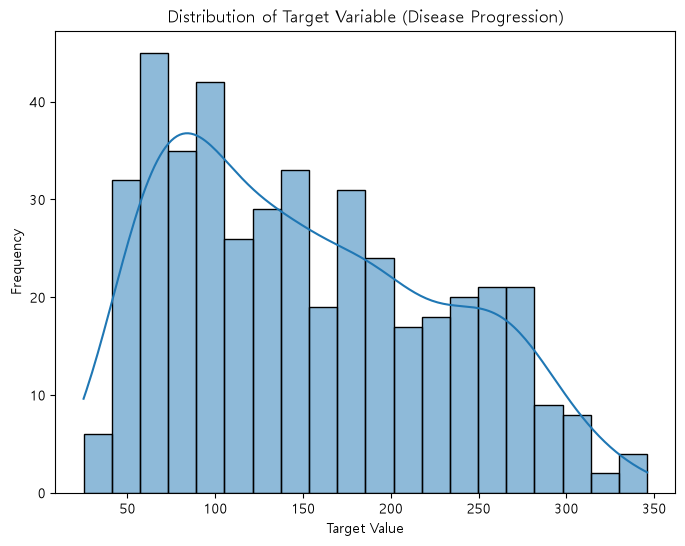

In [7]:
# 히스토그램으로 타겟 값 분포 확인
plt.figure(figsize=(8, 6))
sns.histplot(df['target'], bins=20, kde=True)
plt.title("Distribution of Target Variable (Disease Progression)")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

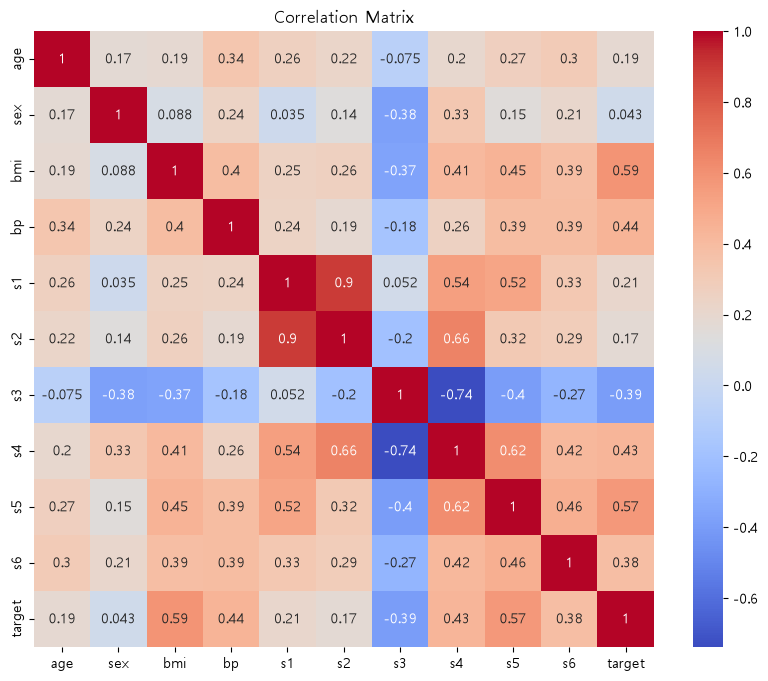

In [8]:
# 상관 행렬 및 히트맵 시각화
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

         age   sex   bmi    bp    s1    s2    s3    s4    s5    s6  target
age     1.00  0.17  0.19  0.34  0.26  0.22 -0.08  0.20  0.27  0.30    0.19
sex     0.17  1.00  0.09  0.24  0.04  0.14 -0.38  0.33  0.15  0.21    0.04
bmi     0.19  0.09  1.00  0.40  0.25  0.26 -0.37  0.41  0.45  0.39    0.59
bp      0.34  0.24  0.40  1.00  0.24  0.19 -0.18  0.26  0.39  0.39    0.44
s1      0.26  0.04  0.25  0.24  1.00  0.90  0.05  0.54  0.52  0.33    0.21
s2      0.22  0.14  0.26  0.19  0.90  1.00 -0.20  0.66  0.32  0.29    0.17
s3     -0.08 -0.38 -0.37 -0.18  0.05 -0.20  1.00 -0.74 -0.40 -0.27   -0.39
s4      0.20  0.33  0.41  0.26  0.54  0.66 -0.74  1.00  0.62  0.42    0.43
s5      0.27  0.15  0.45  0.39  0.52  0.32 -0.40  0.62  1.00  0.46    0.57
s6      0.30  0.21  0.39  0.39  0.33  0.29 -0.27  0.42  0.46  1.00    0.38
target  0.19  0.04  0.59  0.44  0.21  0.17 -0.39  0.43  0.57  0.38    1.00
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1  

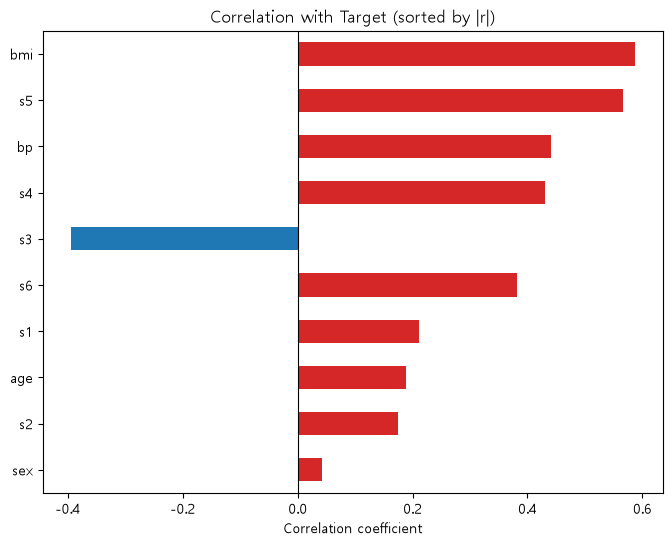

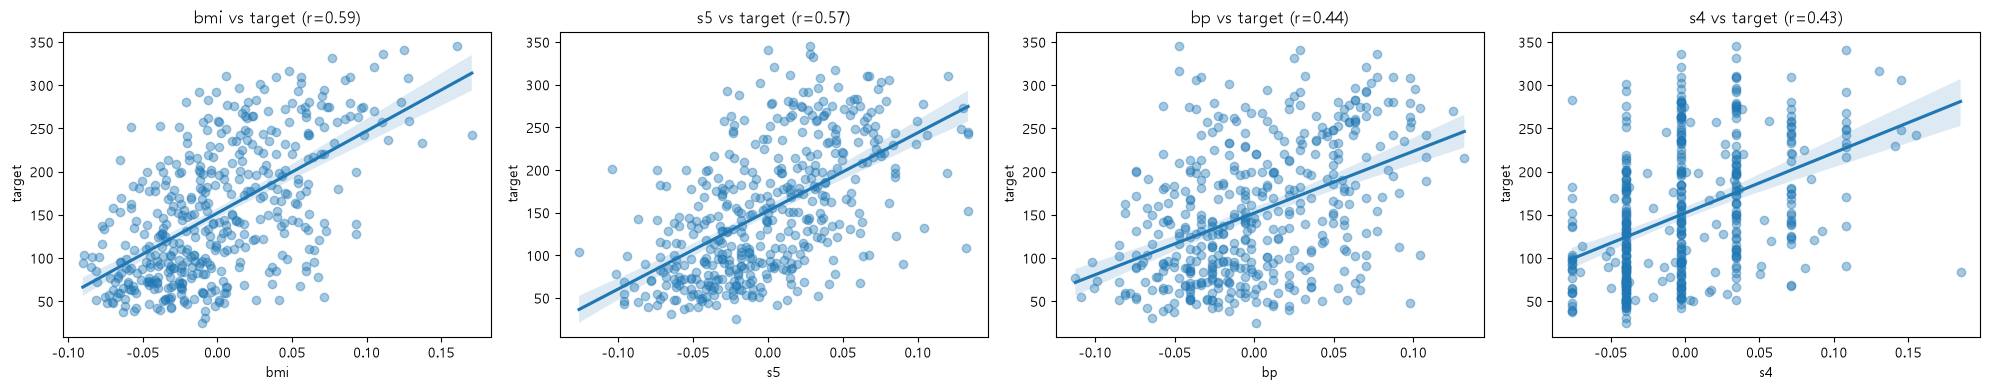

In [9]:
# Q1-1: 어떤 피처(특성)가 가장 중요한지, 직접 데이터를 분석해보세요.
# Q1-2: 어떤 피처가 'target'과 가장 높은 상관관계를 가지나요?

# 상관 행렬을 값으로 직접 확인 (히트맵 색으로는 미묘한 차이 구분이 어려움)
pd.set_option('display.width', 120)
print(df.corr().round(2))

# target과의 상관관계를 절댓값 기준으로 정렬
target_corr = df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print(target_corr)

plt.figure(figsize=(8, 6))
colors = ['tab:red' if v > 0 else 'tab:blue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.gca().invert_yaxis()
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Correlation with Target (sorted by |r|)")
plt.xlabel("Correlation coefficient")
plt.show()

# 상관관계 상위 4개 피처는 target과 실제로 어떤 모양의 관계인지 산점도로 확인
top_features = target_corr.abs().sort_values(ascending=False).index[:4]
fig, axes = plt.subplots(1, len(top_features), figsize=(20, 4))
for ax, feat in zip(axes, top_features):
    sns.regplot(x=df[feat], y=df['target'], ax=ax, scatter_kws={'alpha': 0.4})
    ax.set_title(f"{feat} vs target (r={target_corr[feat]:.2f})")
plt.tight_layout()
plt.show()

**A1-2.** target과 가장 높은 상관관계를 가지는 피처는 **bmi (r=0.586)**이고, **s5 (r=0.566)**가 근소한 차이로 뒤를 잇는다. 그다음은 bp(0.441), s4(0.430), s3(-0.395), s6(0.382) 순이며, age·s1·s2·sex는 상대적으로 약한 상관을 보인다.

**A1-1.** 단순 상관관계 기준으로는 **bmi(체질량지수)와 s5(중성지방 로그값)**가 당뇨병 진행도를 가장 잘 설명하는 피처로 보인다. 산점도로 확인해도 이 두 피처는 target과 뚜렷한 양의 선형관계를 보인다. 다만 s1과 s2처럼 서로 강하게 얽혀있는(r=0.90) 피처 쌍이 존재하는 걸 보면, 상관관계만으로 "중요도"를 단정하기보다는 다중공선성(multicollinearity)의 가능성을 염두에 둘 필요가 있다.

**흥미로운 관찰: 왜 s3만 음의 상관일까?** 상관 행렬을 값으로 보면 age, sex, bmi, bp, s1, s2, s4, s5, s6는 서로 대부분 양의 상관을 가지는데, **s3(HDL 콜레스테롤)만 유독 나머지 피처 대부분과 음의 상관**을 보인다. 이는 우연이 아니라 도메인 지식으로 설명이 된다.

- s3는 **HDL(고밀도 지단백)**, 흔히 "좋은 콜레스테롤"이라 불리는 지표다. 혈관에 쌓인 지질을 간으로 회수해 처리하는 역할을 해서, 수치가 높을수록 대사적으로 건강한 상태를 의미한다.
- 반면 s1(총콜레스테롤), s2(LDL, "나쁜 콜레스테롤"), s5(중성지방), s6(혈당) 등은 수치가 높을수록 대사증후군·인슐린저항성과 관련된 "위험" 방향의 지표다. 임상적으로 중성지방이 높고 인슐린저항성이 있는 사람일수록 HDL은 낮게 나타나는 패턴이 잘 알려져 있어, s3와 이들 지표가 반대로 움직이는 것은 생리학적으로 자연스럽다.
- 특히 **s4(TC/HDL 비율)**는 정의 자체가 총콜레스테롤을 HDL로 나눈 값이라, HDL(s3)이 분모에 들어간다. 따라서 s3가 낮아지면 s4는 커질 수밖에 없어 둘 사이에 강한 음의 상관(r=-0.74)이 수학적으로도 보장된다.

즉 s3만 방향이 반대인 이유는 "좋은 콜레스테롤"과 "나쁜 콜레스테롤/대사 위험 지표"가 개념적으로 반대 방향을 가리키기 때문이며, 이는 데이터의 잡음이 아니라 실제 생리학적 관계가 반영된 결과로 해석할 수 있다.

또한 s1(총콜레스테롤)은 정의상 s2, s3, s5의 가중합으로 계산되는 값이다. 따라서 이들 간의 높은 상관관계는 우연이 아니라 구조적으로 예정된 결과이며, 이는 회귀 모델에서 다중공선성을 유발할 가능성이 있는 대표적인 사례로 볼 수 있다.

## 2. 데이터 전처리: 데이터 분할 및 스케일링


In [10]:
# 훈련 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Q2: 데이터 분할 비율을 70:30 또는 90:10으로 변경하면 결과는 어떻게 달라질까요?

                            R2_mean    R2_std     MSE_mean     MSE_std
7:3 (train=309, test=132)  0.473703  0.047286  3031.478696  230.821251
8:2 (train=353, test=88)   0.458273  0.058308  3041.916340  219.832569
9:1 (train=397, test=44)   0.448758  0.088951  3105.413618  397.358444


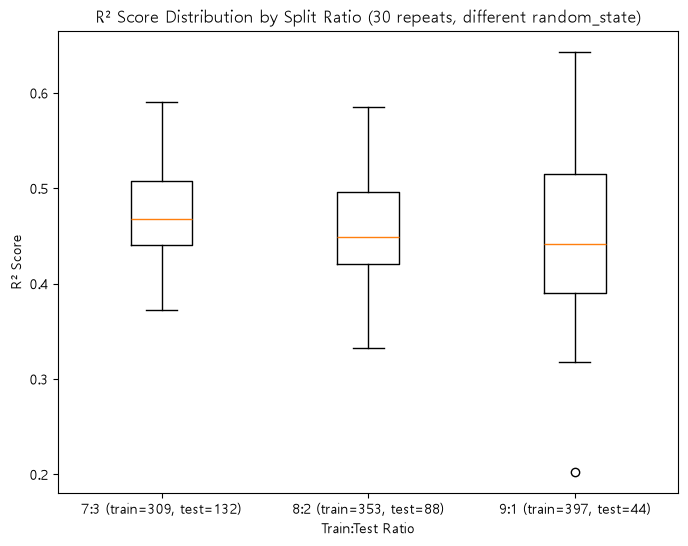

In [12]:
# Q2 실험: 분할 비율(7:3, 8:2, 9:1)에 따라 훈련 안정성과 평가 안정성이 어떻게 달라지는지 확인
split_ratios = [0.3, 0.2, 0.1]  # test_size 기준: 7:3, 8:2, 9:1
n_repeats = 30  # random_state를 바꿔가며 반복 실행 -> 분할에 따른 변동성(안정성) 확인

mse_records, r2_records = {}, {}

for test_size in split_ratios:
    mses, r2s = [], []
    for seed in range(n_repeats):
        X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=seed)

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_te_scaled = scaler.transform(X_te)

        m = LinearRegression()
        m.fit(X_tr_scaled, y_tr)
        y_pred = m.predict(X_te_scaled)

        mses.append(mean_squared_error(y_te, y_pred))
        r2s.append(r2_score(y_te, y_pred))

    n_train, n_test = int(len(X) * (1 - test_size)), int(len(X) * test_size)
    label = f"{round((1 - test_size) * 10)}:{round(test_size * 10)} (train={n_train}, test={n_test})"
    mse_records[label] = mses
    r2_records[label] = r2s

# 비율별 평균/표준편차 요약 (표준편차가 클수록 평가 결과가 불안정하다는 뜻)
summary = pd.DataFrame({
    'R2_mean': [np.mean(v) for v in r2_records.values()],
    'R2_std':  [np.std(v) for v in r2_records.values()],
    'MSE_mean': [np.mean(v) for v in mse_records.values()],
    'MSE_std':  [np.std(v) for v in mse_records.values()],
}, index=list(r2_records.keys()))
print(summary)

# R² 분포를 boxplot으로 시각화 -> 테스트셋이 작을수록 값이 더 크게 흩어지는지 눈으로 확인
plt.figure(figsize=(8, 6))
plt.boxplot(r2_records.values(), tick_labels=r2_records.keys())
plt.title(f"R² Score Distribution by Split Ratio ({n_repeats} repeats, different random_state)")
plt.ylabel("R² Score")
plt.xlabel("Train:Test Ratio")
plt.show()

Q2 결과: A2. 데이터 분할 비율을 7:3, 8:2, 9:1로 바꿔가며 각각 30회 반복 실험한 결과는 다음과 같다.

1) 평균 성능(R², MSE)은 비율에 따라 큰 차이가 없다
R² 평균이 0.474 → 0.458 → 0.449로 아주 소폭 낮아지긴 하지만, 이 차이(0.025)는 R² 표준편차(0.05~0.09)보다도 작은 수준이라 "훈련 데이터가 많아져서 모델이 더 나빠졌다"고 해석하기는 어렵다. 사실상 노이즈 범위 안의 차이다. → 이전에 예상했던 대로, 이 정도 데이터 규모(442개)와 단순 선형회귀 모델에서는 분할 비율이 과대/과소적합에 미치는 영향은 미미하다.

2) 반면 평가의 변동성(표준편차)은 테스트셋이 작아질수록 뚜렷하게 커진다
R² 표준편차가 0.047 → 0.058 → 0.089로, 테스트셋이 132개 → 88개 → 44개로 줄어들수록 꾸준히 증가한다. MSE 표준편차도 9:1 구간에서 397.4로 다른 비율(약 220~230) 대비 눈에 띄게 뛴다. 즉 테스트셋이 작을수록 "어떤 샘플이 뽑혔는지"에 따라 평가 점수가 크게 출렁인다는 예상이 실험으로 확인된다.

3) boxplot에서도 같은 패턴이 시각적으로 드러난다
9:1 비율의 박스가 가장 넓게 퍼져 있고, R²≈0.2인 이상치(outlier)까지 하나 관측된다. 테스트 샘플이 44개뿐이다 보니, 우연히 예측하기 어려운 샘플들이 몰린 한 번의 분할만으로도 점수가 크게 떨어질 수 있음을 보여준다. 반면 7:3 비율은 박스가 가장 좁고 이상치도 없어, 세 비율 중 평가 결과가 가장 안정적이다.

결론
분할 비율은 (이 데이터·모델 조합에서는) 모델의 과대/과소적합보다 "평가 신뢰도"에 더 직접적인 영향을 준다. 테스트셋을 너무 작게 가져가면(9:1) 얻은 점수 하나만으로 모델을 판단하기 위험하고, 반대로 테스트셋을 너무 크게 가져가면(7:3, 훈련 데이터 감소) 모델 성능 자체가 살짝 손해 볼 여지가 있다. 지금 데이터 규모라면 8:2 정도가 학습 데이터 양과 평가 안정성 사이의 합리적인 절충점으로 보인다.



In [13]:
# 스케일링(표준화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

scaler.fit(X_train) - 각 피처 별로 평균과 표준편차를 계산해서 객체 내부에 저장. 실제 데이터 변환은 하지 않고, 기준값만 구함. 계산 결과는 scaler.mean, scaler.scale에 저장.

transform()-저장된 통계치로 변환만 실행. - fit()에 이미 계산해둔 mean, std를 갖고 정규화만 적용. 새로운 통계치를 계산하기 보다 기존 걸 그대로 재사용

fit-transform - 위 둘을 한 번에

test 데이터에서도 fit_transform을 쓰면, 테스트 데이터만의 평균/표준편차도 다시 계산하게 되기에, 데이터 누수 문제가 생기고, 훈련 때 배운 기준과 테스트 때 적용 기준이 달라져 모델이 학습한 스케일 감각과 실제 평가 시 스케일이 어긋남.

즉 StandardScaler은 클래스, scaler은 인스턴스로, fit을 하면 그 결과를 내부 속성으로 기억하다가 transform등을 할 때 내부 속성을 써먹음

In [14]:
# Q3: 스케일링을 하지 않고 학습하면 어떤 결과가 나올까요? 한 번 실험해 보세요.

In [15]:
# Q3 실험: 스케일링 유무에 따라 LinearRegression 결과가 달라지는지 비교
# (cell-20에서 X_train/X_test가 이미 스케일링된 값으로 덮어써졌으므로, 동일한 random_state로 원본 분할을 다시 만들어 비교)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

# (1) 스케일링 없이 그대로 학습
model_unscaled = LinearRegression()
model_unscaled.fit(X_train_raw, y_train_raw)
pred_unscaled = model_unscaled.predict(X_test_raw)

# (2) 스케일링 후 학습
scaler_q3 = StandardScaler()
X_train_scaled = scaler_q3.fit_transform(X_train_raw)
X_test_scaled = scaler_q3.transform(X_test_raw)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train_raw)
pred_scaled = model_scaled.predict(X_test_scaled)

# 성능 비교
print("[성능 비교]")
print(f"  스케일링 X -> MSE: {mean_squared_error(y_test_raw, pred_unscaled):.4f}, R²: {r2_score(y_test_raw, pred_unscaled):.4f}")
print(f"  스케일링 O -> MSE: {mean_squared_error(y_test_raw, pred_scaled):.4f}, R²: {r2_score(y_test_raw, pred_scaled):.4f}")

# 계수 비교
coef_compare = pd.DataFrame({
    'feature': feature_names,
    'coef_unscaled': model_unscaled.coef_,
    'coef_scaled': model_scaled.coef_,
}).round(3)
print("\n[계수 비교]")
print(coef_compare)

[성능 비교]
  스케일링 X -> MSE: 2900.1936, R²: 0.4526
  스케일링 O -> MSE: 2900.1936, R²: 0.4526

[계수 비교]
  feature  coef_unscaled  coef_scaled
0     age         37.904        1.754
1     sex       -241.964      -11.512
2     bmi        542.429       25.607
3      bp        347.704       16.829
4      s1       -931.489      -44.449
5      s2        518.062       24.641
6      s3        163.420        7.677
7      s4        275.318       13.139
8      s5        736.199       35.161
9      s6         48.671        2.351


스케일링 유무에 따라 LinearRegression을 비교 실험한 결과에서 

1) 예측 성능은 완전히 동일하다. 일반 선형회귀는 닫힌 형태 해를 구하는 방식이라 입력 피처를 스케일링해도 찾아내는 회귀 관계 자체는 수학적으로 동일하기 때문이다. 즉 스케일링을 한다고 모델의 예측 성능이 개선되지는 않는다

2) 반면 계수는 크게 달라진다. s1의 경우 raq 계수와 scaled 계수의 비율이 약 21배인데, 이는 diabetes 데이터의 각 피처 표준편차의 역수와 정확히 일치한다. 즉 계수가 달라지는 건 관계가 바뀐 것이 아니라 raw 단위 1당 효과에서 1표준편차당 효과로 측정 단위가 바뀐 것이다.

3) 그러나 diabetes 데이터 기준 raw 표준편차가 모두 동일하기에, raw 계수와 scaled 계수 모두 같은 배율로 커졌을 뿐 상대적 크기 순서는 그대로 유지된다.(diabetes 데이터가 sklearn에서 이미 모든 피처를 동일한 스케일로 정규화해 제공하기에). 만약 나이와 연봉처럼 원래 표준편차가 서로 크게 달랐다면, 표준편차가 큰 피처는 raw 계수가 비정상적으로 작게, 표준편차가 작은 피처는 비정상적으로 크게 나와 실제 중요도를 왜곡 해석했을 것이다.

4) 이 데이터·모델(diabetes + LinearRegression) 조합에서는 스케일링이 성능에도, 심지어 계수의 상대적 해석에도 실질적 영향을 주지 않았다. 하지만 이는 데이터가 이미 사전 정규화되어 있었기 때문에 생긴 우연이며, 일반적인 데이터에서는 (a) 정규화 기반이 아닌 모델(KNN, SVM, 정규화 회귀 등)에서는 성능 자체가 달라지고, (b) 어떤 모델이든 raw 계수로 피처 중요도를 비교하려면 왜곡된 해석을 할 위험이 있으므로, 스케일링을 습관적으로 적용하는 것이 안전한 관행으로 보인다.

In [16]:
# (선택/보너스) Q3 대조군: 거리 기반 모델(KNN)은 스케일링에 얼마나 민감한지 비교
# -> 선형회귀와 달리 KNN은 "거리"로 예측하므로, 값이 큰 피처가 거리 계산을 지배해 성능이 실제로 달라짐
from sklearn.neighbors import KNeighborsRegressor

knn_unscaled = KNeighborsRegressor(n_neighbors=5)
knn_unscaled.fit(X_train_raw, y_train_raw)
knn_pred_unscaled = knn_unscaled.predict(X_test_raw)

knn_scaled = KNeighborsRegressor(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train_raw)
knn_pred_scaled = knn_scaled.predict(X_test_scaled)

print("[KNN 성능 비교]")
print(f"  스케일링 X -> MSE: {mean_squared_error(y_test_raw, knn_pred_unscaled):.4f}, R²: {r2_score(y_test_raw, knn_pred_unscaled):.4f}")
print(f"  스케일링 O -> MSE: {mean_squared_error(y_test_raw, knn_pred_scaled):.4f}, R²: {r2_score(y_test_raw, knn_pred_scaled):.4f}")

[KNN 성능 비교]
  스케일링 X -> MSE: 3019.0755, R²: 0.4302
  스케일링 O -> MSE: 3047.4499, R²: 0.4248


diabetes 데이터의 피처는 모두 동일한 표준편차로 사전 정규화 되어 있어서 KNN도 차이가 크게 나지 않는 것으로 보임. 

## 3. 모델 적합 (선형 회귀)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)  # 학습 진행

# 모델의 가중치 출력
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [  1.75375799 -11.51180908  25.60712144  16.82887167 -44.44885564
  24.64095356   7.67697768  13.1387839   35.16119521   2.35136365]
Model Intercept: 153.73654390934846


# Q4: 모델의 계수를 분석해보세요. 어떤 피처가 타겟에 가장 큰 영향을 미치는지 확인하세요

1. 스케일링 덕분에 계수를 직접 비교할 수 있게 됐고, bmi·s5는 상관관계 분석과 회귀계수 분석 양쪽에서 모두 상위권이라 가장 신뢰할 수 있는 중요 피처로 볼 수 있다.
2. 반면 s1은 단순 상관관계(0.212)에서는 약했는데 회귀계수에서는 1위(-44.4)로 급등하는 역전이 나타난다. 이는 s1이 target에 진짜 강한 영향을 미쳐서라기보다, Q1에서 짚었던 s1-s2 다중공선성(r=0.90) 때문일 가능성이 크다 — 서로 강하게 얽힌 두 피처가 회귀 과정에서 계수를 나눠 갖거나 한쪽으로 쏠리면서 불안정해진 결과로 해석된다.
3. 따라서 "계수가 크다 = 무조건 중요하다"고 단순하게 결론 내리기보다는, **상관관계 분석과 회귀계수 분석에서 일관되게 상위권인 피처(bmi, s5)**를 더 신뢰할 수 있는 중요 피처로 보고, s1처럼 두 분석 결과가 크게 어긋나는 경우는 다중공선성 같은 구조적 원인을 의심해봐야 한다.



In [18]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test)
y_pred

array([139.5475584 , 179.51720835, 134.03875572, 291.41702925,
       123.78965872,  92.1723465 , 258.23238899, 181.33732057,
        90.22411311, 108.63375858,  94.13865744, 168.43486358,
        53.5047888 , 206.63081659, 100.12925869, 130.66657085,
       219.53071499, 250.7803234 , 196.3688346 , 218.57511815,
       207.35050182,  88.48340941,  70.43285917, 188.95914235,
       154.8868162 , 159.36170122, 188.31263363, 180.39094033,
        47.99046561, 108.97453871, 174.77897633,  86.36406656,
       132.95761215, 184.53819483, 173.83220911, 190.35858492,
       124.4156176 , 119.65110656, 147.95168682,  59.05405241,
        71.62331856, 107.68284704, 165.45365458, 155.00975931,
       171.04799096,  61.45761356,  71.66672581, 114.96732206,
        51.57975523, 167.57599528, 152.52291955,  62.95568515,
       103.49741722, 109.20751489, 175.64118426, 154.60296242,
        94.41704366, 210.74209145, 120.2566205 ,  77.61585399,
       187.93203995, 206.49337474, 140.63167076, 105.59

## 4. 모델 평가 Evaluation

In [19]:
# 모델 평가

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 2900.19
R² Score: 0.45


In [20]:
# (선택) Q5: MSE가 높거나 R² 점수가 낮다면, 데이터를 더 분석하거나 다른 모델을 시도해보세요.
# (선택) Q6: 선형 회귀 외에 Decision Tree, Random Forest를 사용해 결과를 비교해보세요.

In [21]:
import numpy as np

In [22]:
# Q5 실험 (1): 베이스라인(훈련 평균 예측) 대비 현재 모델이 얼마나 오차를 줄였는지 확인
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"[베이스라인 (훈련셋 평균으로만 예측)] MSE: {baseline_mse:.2f}, R²: {baseline_r2:.4f}")
print(f"[현재 LinearRegression]            MSE: {mse:.2f}, R²: {r2:.4f}")

[베이스라인 (훈련셋 평균으로만 예측)] MSE: 5361.53, R²: -0.0120
[현재 LinearRegression]            MSE: 2900.19, R²: 0.4526


   n_components  explained_variance_ratio        MSE      R2
0             1                    0.3969  3572.5656  0.3257
1             2                    0.5447  3495.0524  0.3403
2             3                    0.6698  3627.3925  0.3153
3             4                    0.7709  2874.1781  0.4575
4             5                    0.8368  2881.4962  0.4561
5             6                    0.8961  2977.4563  0.4380
6             7                    0.9481  2892.4366  0.4541
7             8                    0.9915  2883.4311  0.4558
8             9                    0.9991  2887.3835  0.4550
9            10                    1.0000  2900.1936  0.4526

[PCR 최고 성능] n_components=4 -> MSE: 2874.18, R²: 0.4575


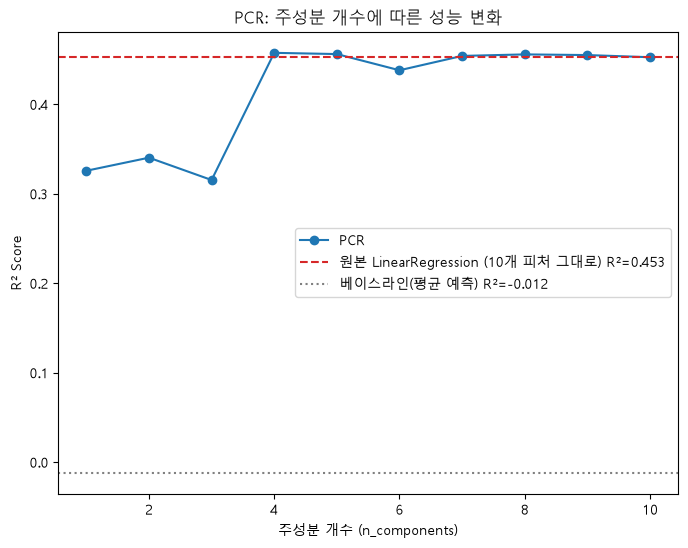

In [23]:
# Q5 실험 (2): PCR (Principal Component Regression) - PCA로 차원을 축소한 뒤 회귀를 적합
# 다중공선성(s1-s2, s3-s4 등)이 성능을 깎아먹었다면, 서로 얽힌 정보를 압축하는 PCA가 도움이 될 수 있는지 확인
from sklearn.decomposition import PCA

pcr_results = []
for n_comp in range(1, X_train.shape[1] + 1):
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train)   # X_train은 이미 스케일링된 상태 (cell-20)
    X_test_pca = pca.transform(X_test)

    pcr_model = LinearRegression()
    pcr_model.fit(X_train_pca, y_train)
    pcr_pred = pcr_model.predict(X_test_pca)

    pcr_results.append({
        'n_components': n_comp,
        'explained_variance_ratio': pca.explained_variance_ratio_.sum(),
        'MSE': mean_squared_error(y_test, pcr_pred),
        'R2': r2_score(y_test, pcr_pred),
    })

pcr_df = pd.DataFrame(pcr_results)
print(pcr_df.round(4))

best_pcr = pcr_df.loc[pcr_df['R2'].idxmax()]
print(f"\n[PCR 최고 성능] n_components={int(best_pcr['n_components'])} -> MSE: {best_pcr['MSE']:.2f}, R²: {best_pcr['R2']:.4f}")

# 주성분 개수에 따른 R² 변화 시각화 (원본 LinearRegression, 베이스라인과 비교)
plt.figure(figsize=(8, 6))
plt.plot(pcr_df['n_components'], pcr_df['R2'], marker='o', label='PCR')
plt.axhline(r2, color='tab:red', linestyle='--', label=f'원본 LinearRegression (10개 피처 그대로) R²={r2:.3f}')
plt.axhline(baseline_r2, color='gray', linestyle=':', label=f'베이스라인(평균 예측) R²={baseline_r2:.3f}')
plt.xlabel('주성분 개수 (n_components)')
plt.ylabel('R² Score')
plt.title('PCR: 주성분 개수에 따른 성능 변화')
plt.legend()
plt.show()

# Q5 에서 진행한 PCR 해석

주성분 개수(n_components)에 따른 R² 변화를 보면, n=3까지는 R²가 0.310.34 수준으로 낮다가 n=4에서 급격히 뛰어올라 원본 10개 피처를 그대로 쓴 LinearRegression의 R²(0.453)와 거의 같은 수준(약 0.45)에 도달하고, 이후 n=10까지는 거의 변화가 없다(사이 n=6에서 소폭 하락하는 구간이 있지만 노이즈 범위로 보인다).

이 패턴은 두 가지를 동시에 말해준다.

1) 10개 피처의 예측 정보는 사실상 4개의 주성분에 압축되어 있다.
주성분 4개만으로 원본 10개 피처를 다 쓴 것과 동일한 설명력을 낸다는 것은, 나머지 6개 방향(주성분)이 target을 설명하는 데 거의 기여하지 않는다는 뜻이다. 이는 Q1·Q4에서 확인한 다중공선성(s1-s2 r=0.90, s3-s4 r=-0.74 등 지질 패널 피처들이 서로 얽혀 있는 구조)과 정확히 일치하는 결과다 — 서로 중복된 정보를 담고 있던 피처들이 PCA를 거치면서 소수의 독립적인 성분으로 압축된 것으로 해석할 수 있다.

2) 동시에, 주성분을 아무리 늘려도 R²는 약 0.45를 넘지 못한다.
이는 지금까지 설명 안 된 나머지 약 55%의 변동이 "충분히 많은 선형 조합을 못 써서" 생긴 문제가 아니라는 뜻이다. 10개 피처가 가진 선형적 정보를 최대한 활용해도(주성분 10개 = 원본 피처 10개와 사실상 동일) 이 이상은 설명이 안 된다. 즉 이 상한(ceiling)은 차원 축소나 피처 결합 방식의 문제가 아니라, ①target과 피처들 사이에 비선형 관계가 존재하거나 ②지금 가진 10개 측정치만으로는 설명할 수 없는 다른 요인(측정되지 않은 변수, 개인차, 노이즈)이 남아있다는 근거로 볼 수 있다.

정리
PCR 결과는 "다중공선성으로 인한 정보 중복"과 "선형 모델 자체의 설명력 한계"를 동시에 보여준다. 전자는 주성분 4개로도 충분하다는 사실이, 후자는 그 이상 늘려도 R²가 안 오른다는 사실이 뒷받침한다. 이 한계를 넘어서려면 비선형 관계를 학습할 수 있는 모델(Q6의 Random Forest 등)이 필요하다는 자연스러운 다음 단계로 이어진다.



[Random Forest] MSE: 2980.54, R²: 0.4374

[모델 비교]
                         Model        MSE      R2
0                 베이스라인(평균 예측)  5361.5335 -0.0120
1  LinearRegression(원본 10개 피처)  2900.1936  0.4526
2         PCR (n_components=4)  2874.1781  0.4575
3                 RandomForest  2980.5415  0.4374


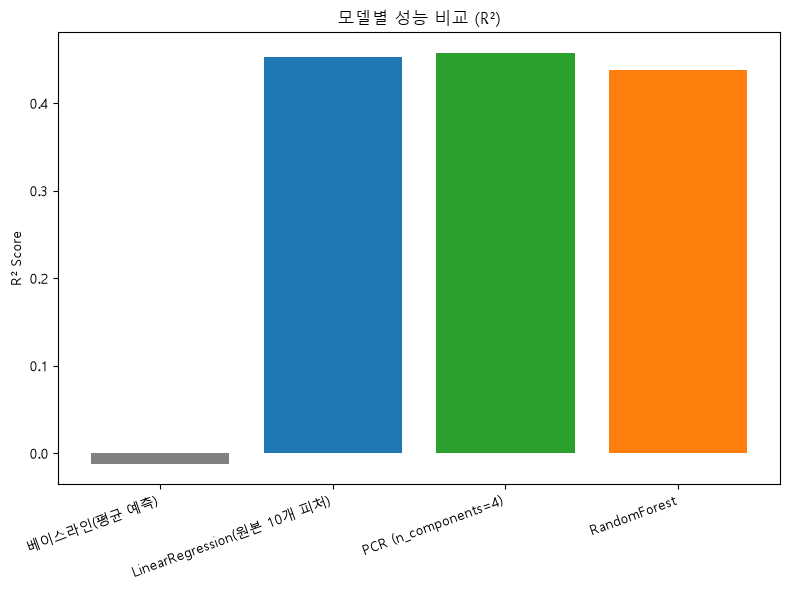


[Random Forest Feature Importance]
bmi    0.353246
s5     0.236397
bp     0.088485
s6     0.068979
s2     0.059566
age    0.057964
s1     0.052122
s3     0.050881
s4     0.023055
sex    0.009305
dtype: float64


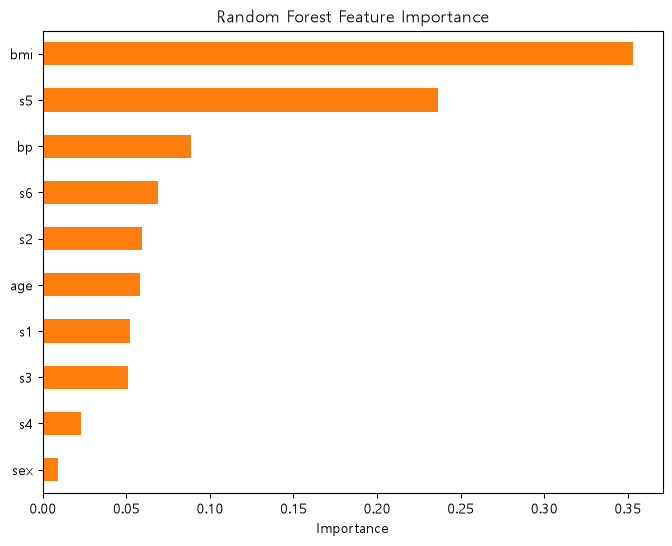

In [24]:
# Q6: Random Forest로 비선형 관계까지 학습했을 때 성능이 개선되는지 비교
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)  # 트리 기반 모델은 스케일링에 영향받지 않지만, 파이프라인 일관성을 위해 그대로 사용
rf_pred = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"[Random Forest] MSE: {rf_mse:.2f}, R²: {rf_r2:.4f}")

# 지금까지 시도한 모델들을 한눈에 비교
model_comparison = pd.DataFrame({
    'Model': ['베이스라인(평균 예측)', 'LinearRegression(원본 10개 피처)',
              f'PCR (n_components={int(best_pcr["n_components"])})', 'RandomForest'],
    'MSE': [baseline_mse, mse, best_pcr['MSE'], rf_mse],
    'R2':  [baseline_r2, r2, best_pcr['R2'], rf_r2],
}).round(4)
print("\n[모델 비교]")
print(model_comparison)

plt.figure(figsize=(8, 6))
plt.bar(model_comparison['Model'], model_comparison['R2'], color=['gray', 'tab:blue', 'tab:green', 'tab:orange'])
plt.ylabel('R² Score')
plt.title('모델별 성능 비교 (R²)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Random Forest의 피처 중요도 -> Q1(상관관계), Q4(회귀계수)와 비교해볼 수 있는 세 번째 지표
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\n[Random Forest Feature Importance]")
print(rf_importance)

plt.figure(figsize=(8, 6))
rf_importance.plot(kind='barh', color='tab:orange')
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

# Q6 Random Forest 해석

1) 예상과 달리 성능이 오르지 않았다 — 오히려 살짝 낮다

비선형 관계를 잡아낼 수 있는 Random Forest를 시도해봤지만, R²=0.436으로 LinearRegression(0.453)이나 PCR(0.456)보다 오히려 소폭 낮게 나왔다. 만약 target과 피처들 사이에 강한 비선형 관계나 상호작용이 실제로 존재했다면, 유연한 트리 기반 모델이 그 패턴을 잡아내면서 선형 모델보다 뚜렷하게 나은 성능을 보였어야 한다. 하지만 결과는 그렇지 않았다.

2) 이 결과가 말해주는 것

이는 앞서 세운 가설 — "남은 약 55%의 미설명 변동은 선형 모델이 못 잡는 비선형/상호작용 관계 때문일 것이다" — 을 뒷받침하지 못하는 결과다. 오히려 이 데이터에서는:

target(1년 후 당뇨 진행도)과 10개 baseline 측정치 사이의 관계가 상당 부분 이미 선형에 가깝고,
남은 미설명 변동은 "모델이 못 잡는 숨겨진 패턴"이라기보다, 애초에 이 10개 측정치만으로는 설명이 불가능한 요인들(측정되지 않은 유전적 요인, 생활습관, 개인차, 혹은 target 자체에 내재된 노이즈)에서 온다고 보는 게 더 타당해 보인다.

3) Feature Importance로 본 부가적 발견 — s1의 정체가 드러남

세 가지 다른 방식으로 구한 피처 중요도를 비교해보면 흥미로운 그림이 나온다.
- bmi와 s5는 상관관계·RF importance 양쪽에서 일관되게 1·2위 — 세 가지 서로 다른 방법론이 동의하는 만큼, 가장 신뢰할 수 있는 진짜 중요 피처로 볼 수 있다.
- s1은 RF에서 다시 순위가 크게 떨어졌다(7위, 0.052). RF는 트리 분기 방식으로 중요도를 계산하기 때문에 선형회귀 계수처럼 다중공선성에 의해 값이 왜곡되지 않는다. s1이 RF에서 다시 낮은 순위로 돌아왔다는 것은, Q4에서 관찰한 s1의 회귀계수 급등(1위)이 실제 중요도가 아니라 s1-s2 다중공선성이 만든 통계적 착시였다는 가설을 다른 방법론으로 재확인해주는 결과다.

Random Forest 실험은 두 가지 결론을 준다: (1) 성능 측면에서는 이 데이터의 설명력 한계(~0.45)가 비선형성 부재보다는 데이터 자체의 정보 한계에 가깝다는 것, (2) 피처 중요도 측면에서는 bmi·s5의 중요성과 s1의 다중공선성 착시를 교차검증했다는 것

# 2. **분류 - with Iris dataset**

In [25]:
# 필요한 라이브러리 불러오기
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import set_config

set_config(display='text')  # 모델을 HTML로 예쁘게 표시하려다 Windows 인코딩(cp949) 문제로 에러나는 것 방지

## 1. 데이터 로드 및 탐색

In [26]:
iris = load_iris()
X, y = iris.data, iris.target

feature_names = iris.feature_names
class_names = iris.target_names

In [27]:
# 데이터 크기와 피처 정보 출력
print(f"Dataset Shape: {X.shape}")  # (샘플 수, 피쳐 수) 
print(f"Feature Names: {iris.feature_names}")
print(f"Classes: {iris.target_names}")  # 클래스가 몇 개이고, 어떤 게 있는지 확인해 보세요
print(f"First 5 Samples:\n{X[:5]}")

Dataset Shape: (150, 4)
Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']
First 5 Samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [28]:
# Q1: 각 클래스에 몇 개의 데이터가 있는지 확인해 보세요. 클래스 별 데이터가 균등하게 분포되어 있나요?
unique, counts = np.unique(y, return_counts=True)
class_distribution = {int(k): int(v) for k, v in zip(unique, counts)}
print(f"Class Distribution: {class_distribution}")

Class Distribution: {0: 50, 1: 50, 2: 50}


In [29]:
# 데이터프레임으로 변환하여 탐색
df = pd.DataFrame(X, columns=feature_names)
df['class'] = y

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [31]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


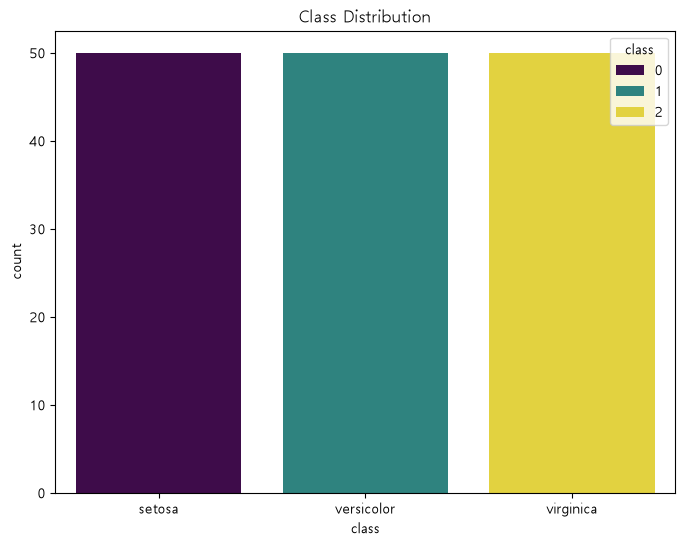

In [32]:
# 클래스별 데이터 분포 확인
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df, palette='viridis', hue='class')
plt.title("Class Distribution")
plt.xticks(ticks=[0, 1, 2], labels=class_names)
plt.show()

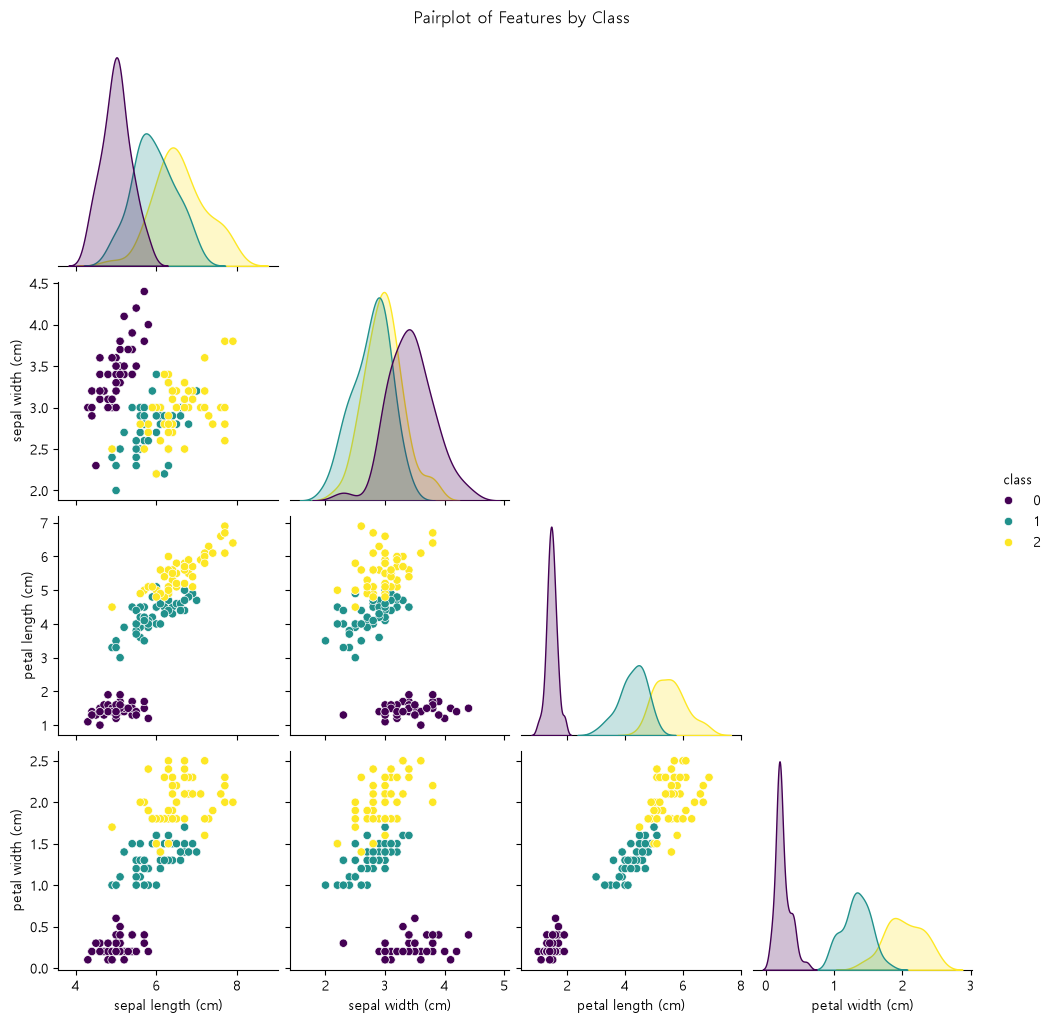

In [33]:
# 피처 간 산점도 행렬
sns.pairplot(df, hue='class', palette='viridis', diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Features by Class", y=1.02)
plt.show()

## 2. 데이터 전처리: 데이터 분할 및 스케일링

In [34]:
# 훈련 데이터와 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
# Q2: stratify를 제외하면 클래스 비율이 어떻게 달라질까요? 확인해 보세요.

테스트셋(30개) 클래스별 개수 통계 (20회 반복, random_state=0~19)
           stratify=y              stratify=None              
                 mean  std min max          mean   std min max
setosa           10.0  0.0  10  10         10.50  2.36   7  16
versicolor       10.0  0.0  10  10         10.25  2.12   5  13
virginica        10.0  0.0  10  10          9.25  1.95   6  13


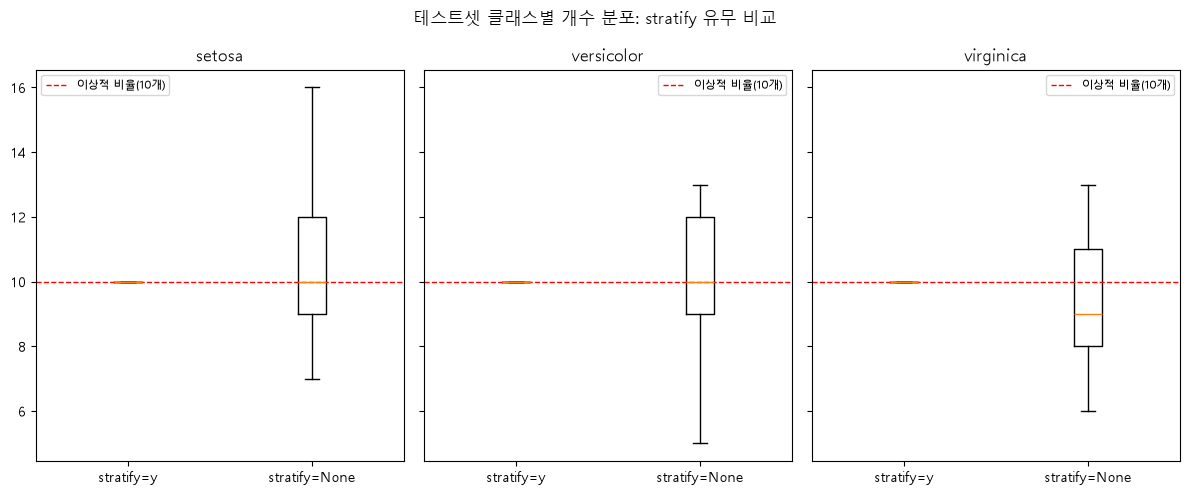

In [36]:
# Q2 실험: stratify 유무에 따라 테스트셋의 클래스 비율이 얼마나 달라지는지 확인
n_repeats = 20

def get_test_class_counts(use_stratify):
    counts_per_run = []
    for seed in range(n_repeats):
        strat = y if use_stratify else None
        _, _, _, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=strat)
        counts_per_run.append(np.bincount(y_te, minlength=3))
    return np.array(counts_per_run)

counts_stratified = get_test_class_counts(True)
counts_no_stratify = get_test_class_counts(False)

summary = pd.DataFrame({
    ('stratify=y', 'mean'): counts_stratified.mean(axis=0),
    ('stratify=y', 'std'):  counts_stratified.std(axis=0),
    ('stratify=y', 'min'):  counts_stratified.min(axis=0),
    ('stratify=y', 'max'):  counts_stratified.max(axis=0),
    ('stratify=None', 'mean'): counts_no_stratify.mean(axis=0),
    ('stratify=None', 'std'):  counts_no_stratify.std(axis=0),
    ('stratify=None', 'min'):  counts_no_stratify.min(axis=0),
    ('stratify=None', 'max'):  counts_no_stratify.max(axis=0),
}, index=class_names).round(2)
print(f"테스트셋(30개) 클래스별 개수 통계 ({n_repeats}회 반복, random_state=0~{n_repeats-1})")
print(summary)

# 클래스별로 stratify 유무에 따른 분포를 boxplot으로 비교
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
for i, cname in enumerate(class_names):
    axes[i].boxplot(
        [counts_stratified[:, i], counts_no_stratify[:, i]],
        tick_labels=['stratify=y', 'stratify=None']
    )
    axes[i].axhline(10, color='red', linestyle='--', linewidth=1, label='이상적 비율(10개)')
    axes[i].set_title(cname)
    axes[i].legend(fontsize=8)
plt.suptitle("테스트셋 클래스별 개수 분포: stratify 유무 비교")
plt.tight_layout()
plt.show()

A2. stratify 유무에 따라 20회 반복 실험한 결과, stratify=y는 항상 정확히 10:10:10(표준편차 0)으로 나뉘는 반면, stratify 없이 무작위로 분할하면 평균은 여전히 10 근처(9.25~10.5)로 비슷하지만 표준편차가 약 2, 범위는 최소 5~최대 16까지 흔들린다. 특히 setosa는 어떤 분할에서는 7개, 어떤 분할에서는 16개까지 뽑혀서 최대-최소 차이가 2배 이상 나기도 한다.

핵심: 이 데이터는 원래 50:50:50으로 완벽하게 균등해서, stratify 없이도 평균적으로는 원래 비율을 잘 따라간다. 하지만 "평균적으로 맞다"는 것과 "매번(한 번 뽑을 때마다) 안정적이다"는 건 다른 이야기다 — 실제로 한 번의 분할만 놓고 보면 특정 클래스가 30개 중 7개(약 23%)만 뽑히거나 16개(약 53%)까지 뽑히는 등 상당히 흔들릴 수 있다는 게 이번 실험으로 확인됐다.

만약 클래스가 원래 불균형했다면 (예: 90:10), 문제는 이보다 훨씬 심각해진다. stratify 없이 무작위로 뽑으면 소수 클래스(전체의 10%)가 테스트셋에 극단적으로 적게 뽑히거나, 운이 나쁘면 아예 하나도 안 뽑힐 수도 있다. 이 경우 그 클래스에 대한 precision/recall은 계산 자체가 불가능하거나(0으로 나누기), 극소수 샘플로만 평가되어 신뢰할 수 없는 값이 나온다. stratify는 이런 극단적 왜곡을 원천적으로 막아준다는 점에서, 클래스가 균형일 때보다 불균형할 때 훨씬 더 중요한 옵션이다.




In [37]:
# 스케일링(표준화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
# Q3: 스케일링을 하지 않고 학습하면 정확도에 어떤 영향을 미칠까요?


# A3. LinearRegression과 SVM은 스케일링에 대한 민감도가 근본적으로 다르다.

1) 회귀(LinearRegression)와의 비교

Q3(회귀)에서 확인했듯이, OLS는 닫힌 형태 수식으로 계수를 구하기 때문에 스케일링을 해도 찾아내는 관계 자체는 수학적으로 동일하고, 예측 성능(R², MSE)은 전혀 바뀌지 않았다. 반면 SVM은 클래스 사이의 마진(margin)을 최대화하는 방식으로 학습하는데, 이 마진은 데이터 포인트 사이의 실제 거리로 계산된다. 따라서 피처 단위가 크면 그 피처가 거리 계산을 지배하게 되고, 결정경계 자체가 달라질 수 있다 — 즉 SVM은 회귀와 달리 스케일링이 정확도에 실제로 영향을 줄 수 있는 모델이다.

2) 이 데이터에서의 예측

iris 피처들의 표준편차를 보면 petal length(1.77)가 sepal width(0.44)보다 약 4배 크다. 스케일링을 안 하면 petal length 쪽 거리 차이가 상대적으로 크게 반영되면서, 결정경계가 petal 쪽에 더 큰 영향을 받을 가능성이 있다.

다만 diabetes 예시(나이 vs 연봉처럼 단위가 수천~수만 배 차이나는 경우)만큼 극단적인 차이는 아니라서, 스케일링 유무에 따른 정확도 차이가 그렇게 크게 벌어지지는 않을 수도 있다

3) EDA와 연결지어 예측

앞서 pairplot 분석에서 확인했듯, petal 관련 피처(petal length, petal width)가 애초에 종 구분에 가장 결정적인 피처였다(setosa가 petal 축에서 완전히 분리됨). 그런데 공교롭게도 이 petal 피처가 표준편차도 가장 크다. 즉 "원래 단위가 커서 거리 계산을 지배하는 피처"와 "원래 분류에 가장 중요한 피처"가 우연히 일치하는 상황이라, 스케일링을 안 해도 오히려 큰 성능 저하가 없거나 미미할 가능성도 있다. 이 부분은 이 데이터의 특수성으로, diabetes처럼 "중요하지 않은데 단위만 큰 피처가 부당하게 결과를 왜곡하는" 상황과는 다르다.

결론 (예상): SVM은 원리적으로 스케일링에 민감한 모델이지만, iris 데이터는 단위 차이가 크지 않고 공교롭게도 단위가 큰 피처가 실제로도 중요한 피처와 겹치기 때문에, 스케일링 유무에 따른 accuracy 차이는 diabetes의 KNN 사례보다도 더 작게(또는 거의 없이) 나타날 가능성이 있다



## 3. 모델 적합 (SVM)

In [45]:
model = SVC(kernel='linear', C=0.1)  # 선형 커널 사용
model.fit(X_train, y_train)  # 모델 학습

SVC(C=0.1, kernel='linear')

In [46]:
# Q4: C 값을 조정해보세요 (예: 0.1, 10). 모델의 성능에 어떤 영향을 미칠까요?

        C  train_accuracy  test_accuracy  n_support_vectors
0    0.01        0.891667       0.866667                106
1    0.10        0.975000       0.933333                 56
2    1.00        0.975000       1.000000                 23
3   10.00        0.975000       0.966667                 14
4  100.00        0.983333       1.000000                 11


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


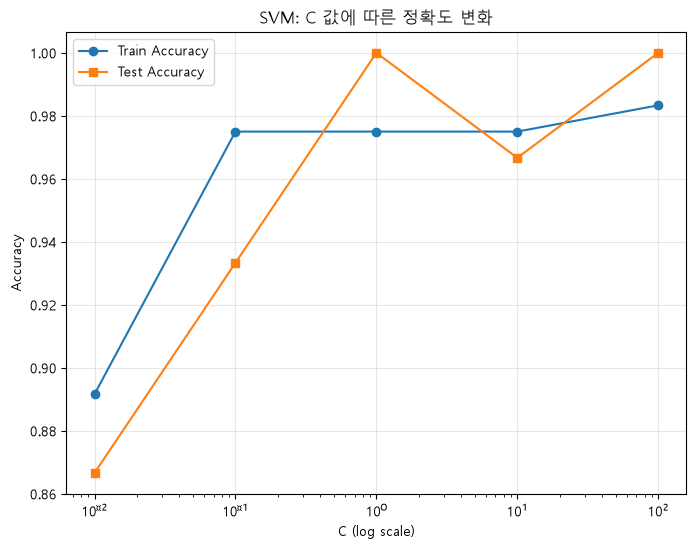

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


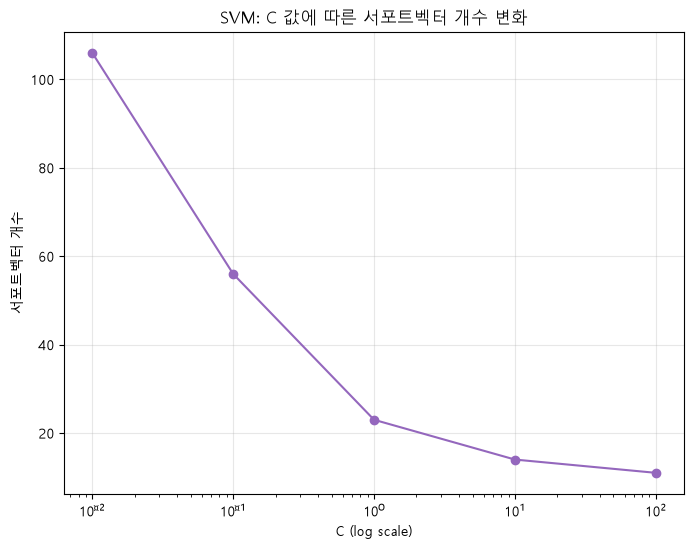

In [47]:
# Q4 실험: SVM의 C 값을 조정하며 성능 변화 비교
C_values = [0.01, 0.1, 1, 10, 100]

c_results = []
for c in C_values:
    m = SVC(kernel='linear', C=c)
    m.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train))
    test_acc = accuracy_score(y_test, m.predict(X_test))
    c_results.append({
        'C': c,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'n_support_vectors': m.support_vectors_.shape[0],
    })

c_df = pd.DataFrame(c_results)
print(c_df)

# C값에 따른 정확도 변화 시각화 (C가 넓은 범위라 x축은 log scale)
plt.figure(figsize=(8, 6))
plt.plot(c_df['C'], c_df['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(c_df['C'], c_df['test_accuracy'], marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy')
plt.title('SVM: C 값에 따른 정확도 변화')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 서포트벡터 개수 변화도 함께 확인 (C가 커질수록 마진이 좁아지며 서포트벡터 수가 줄어드는 경향)
plt.figure(figsize=(8, 6))
plt.plot(c_df['C'], c_df['n_support_vectors'], marker='o', color='tab:purple')
plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('서포트벡터 개수')
plt.title('SVM: C 값에 따른 서포트벡터 개수 변화')
plt.grid(True, alpha=0.3)
plt.show()

# A4. SVM의 규제 파라미터 C를 0.01~100까지 조정하며 정확도와 서포트벡터 개수 변화를 확인했다.

1) C가 너무 작으면(C=0.01) 훈련 정확도부터 낮다 — 과소적합

train accuracy가 0.892로 다섯 값 중 가장 낮고, test accuracy도 0.867로 가장 낮다. C가 작을수록 마진을 넓게 잡고 오분류를 많이 허용하는 방향(강한 규제)이라, 모델이 훈련 데이터조차 제대로 못 맞추는 과소적합 상태에 가깝다. train/test가 동시에 낮다는 게 이 진단의 근거다.

2) C=0.1100 구간에서는 train accuracy가 0.9750.983으로 거의 변화 없이 안정적

C를 키워도 train accuracy가 크게 안 오르는 걸 보면, 이 구간부터는 이미 훈련 데이터를 거의 다 맞추고 있어서(iris가 애초에 petal 기준으로 거의 선형분리 가능한 "쉬운" 데이터라는 걸 pairplot에서 확인했었다) C를 더 키워도 더 맞출 게 별로 안 남아있는 상태로 보인다.

3) test accuracy는 C=1, 100에서 1.0까지 도달 — 그런데 C=10에서 살짝 떨어짐(0.967)

이건 과적합의 신호라기보다는 테스트셋이 30개뿐이라 1개만 틀려도 0.967(29/30)로 떨어지는 구조 때문에 생기는 노이즈로 보는 게 타당하다. train accuracy는 C=10에서도 여전히 0.975로 안정적이라(즉 train/test 격차가 벌어지지 않음), "C가 커서 과적합했다"고 보기엔 근거가 약하다.

4) 서포트벡터 개수는 C가 커질수록 뚜렷하게 감소 (106 → 56 → 23 → 14 → 11)

이건 이론과 정확히 일치하는 부분이다. C가 작을수록 마진이 넓어서 그 마진 안팎의 많은 점들이 "경계에 영향을 주는" 서포트벡터가 되고, C가 커질수록 마진이 좁아지면서 결정경계에 정말로 근접한 소수의 점들만 서포트벡터로 남는다. 마진의 폭이 실제로 변하고 있다는 걸 간접적으로 보여주는 지표다.

5) 결론 — 이 데이터에서는 "C가 커서 과적합"하는 그림이 뚜렷하게 나타나지 않았다

일반적으로 C를 너무 키우면 훈련 데이터에 과하게 맞추다 테스트 성능이 떨어지는(과적합) 패턴을 예상하기 쉬운데, 이 실험에서는 C=100까지도 test accuracy가 오히려 1.0을 유지했다. 이는 iris 데이터가 클래스 간 경계가 원래 뚜렷하고(특히 setosa는 완전 분리, versicolor/virginica도 petal 기준으로는 꽤 잘 갈림) 노이즈가 적은 "쉬운" 데이터셋이라, C를 크게 잡아 마진을 좁혀도 실제로 오버피팅할 만한 노이즈 자체가 별로 없기 때문으로 해석할 수 있다. 반대로 C가 너무 작을 때(0.01)는 모델이 지나치게 단순해져서 훈련 데이터조차 잘 못 맞추는 과소적합이 뚜렷하게 관찰됐다.



In [48]:
# 테스트 데이터로 예측
y_pred = model.predict(X_test)

## 4. 모델 평가 Evaluation 

In [49]:
# 모델 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



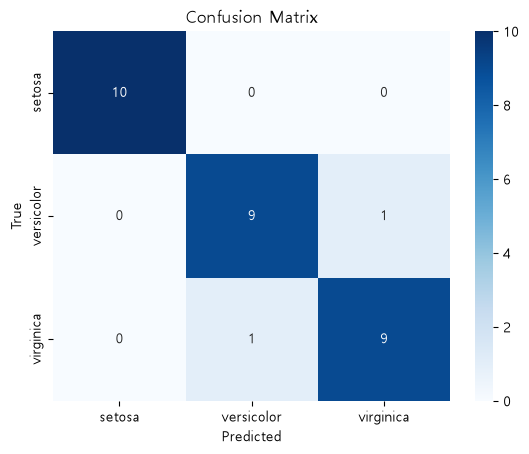

In [50]:
# Confusion Matrix 시각화
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [44]:
# Q6: Confusion Matrix를 보고 결과를 해석해보세요.

# A6

1) setosa는 30개 중 0건 오분류 — 완벽하게 분류됨

setosa 10개는 전부 정확히 예측됐다. 이는 앞선 pairplot 분석에서 확인한 내용과 정확히 일치한다 — petal length/petal width가 들어간 산점도에서 setosa는 다른 두 종과 겹치는 부분이 전혀 없이 완전히 분리되어 있었기 때문에, 모델 입장에서도 헷갈릴 여지가 없는 것이다.

2) 오분류는 전부 versicolor ↔ virginica 사이에서만 발생 (각 1건씩, 대칭적)

versicolor 1개는 virginica로, virginica 1개는 versicolor로 잘못 예측됐다. 이 두 종은 pairplot에서도 sepal 관련 축뿐 아니라 petal 축 일부에서도 경계가 서로 겹쳐 있었던 종들이다. 즉 두 종의 실제 피처 분포 자체가 부분적으로 겹치기 때문에, 아무리 좋은 모델을 쓰더라도 그 겹치는 영역에 위치한 소수의 샘플은 어느 쪽으로 분류해도 틀릴 위험이 구조적으로 존재한다.

3) 결론 — 모델의 결함이 아니라 데이터 구조를 그대로 반영한 결과

오분류 패턴(setosa=0건, versicolor↔virginica만 헷갈림)은 모델 성능의 한계라기보다 EDA 단계에서 이미 예측 가능했던 데이터의 본질적 구조를 그대로 보여준다. 사전에 pairplot으로 세운 "어떤 종끼리 헷갈릴 가능성이 있는가"라는 가설이, 실제 모델의 오분류 결과에서 정확히 검증된 셈이다. 이는 단순히 accuracy 숫자 하나만 봤다면 알 수 없었을 정보로, Confusion Matrix가 "어디서, 왜 틀렸는지"까지 진단할 수 있게 해주는 이유이기도 하다.

